In [2]:
#imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
#input data

In [30]:
# Enter Viral and Bacterial data

viral_data = input("Enter Viral data (CRP, Temperature): ")
bacterial_data = input("Enter Bacterial data (CRP, Temperature): ")

# Convert entered values into matrices
X1 = np.array(eval(viral_data), dtype=float)       # Viral
X2 = np.array(eval(bacterial_data), dtype=float)   # Bacterial

# Combined dataset and labels
X = np.vstack((X1, X2))
y = np.array([0] * len(X1) + [1] * len(X2))

print("\nViral data (CRP, Temperature):")
print(X1)

print("\nBacterial data (CRP, Temperature):")
print(X2)

Enter Viral data (CRP, Temperature): [[40.0,36.0],[11.1,37.2],[30.0,36.5],[21.4,39.4],[10.7,39.6],[3.4,40.7]]
Enter Bacterial data (CRP, Temperature): [[42.0,37.6],[31.1,42.2],[50.0,38.5],[60.4,39.4],[45.7,38.6],[17.3,42.7]]

Viral data (CRP, Temperature):
[[40.  36. ]
 [11.1 37.2]
 [30.  36.5]
 [21.4 39.4]
 [10.7 39.6]
 [ 3.4 40.7]]

Bacterial data (CRP, Temperature):
[[42.  37.6]
 [31.1 42.2]
 [50.  38.5]
 [60.4 39.4]
 [45.7 38.6]
 [17.3 42.7]]


In [31]:
## 3. Visualize the Raw Data


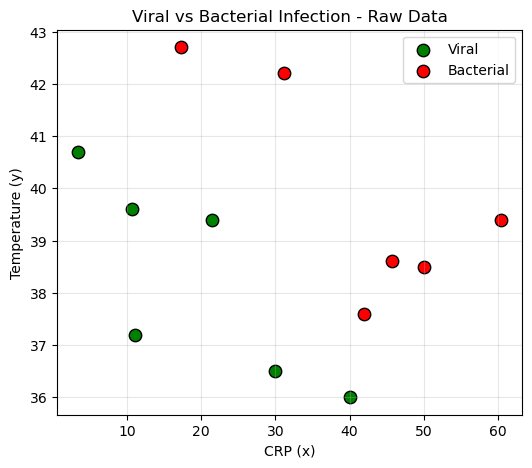

In [32]:
plt.figure(figsize=(6,5))
plt.scatter(X1[:,0], X1[:,1], c='green', label='Viral', s=80, edgecolor='k')
plt.scatter(X2[:,0], X2[:,1], c='red', label='Bacterial', s=80, edgecolor='k')
plt.xlabel('CRP (x)')
plt.ylabel('Temperature (y)')
plt.title('Viral vs Bacterial Infection - Raw Data')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [33]:
## 5. Step 1 — Compute Class Means


In [34]:
mean1 = X1.mean(axis=0)   # Viral mean
mean2 = X2.mean(axis=0)   # Bacterial mean

print('Mean vector (Viral)    :', mean1)
print('Mean vector (Bacterial):', mean2)


Mean vector (Viral)    : [19.43333333 38.23333333]
Mean vector (Bacterial): [41.08333333 39.83333333]


In [35]:
## 6. Covariance Matrices of Viral and Bacterial Classes


In [36]:
cov1 = np.cov(X1, rowvar=False, bias=False)
cov2 = np.cov(X2, rowvar=False, bias=False)

print('Covariance Matrix (Viral):\n', cov1)
print('\nCovariance Matrix (Bacterial):\n', cov2)


Covariance Matrix (Viral):
 [[188.25866667 -20.96533333]
 [-20.96533333   3.67466667]]

Covariance Matrix (Bacterial):
 [[228.02166667 -23.96133333]
 [-23.96133333   4.45866667]]


In [37]:
## 7. Step 2 — Compute Within-Class Scatter Matrix ($S_w$)


In [38]:
def scatter_matrix(X, mean):
    diff = X - mean
    S = np.zeros((X.shape[1], X.shape[1]))
    for row in diff:
        row = row.reshape(-1, 1)
        S += row @ row.T
    return S

S1 = scatter_matrix(X1, mean1)
S2 = scatter_matrix(X2, mean2)
Sw = S1 + S2

print('S1 (Viral scatter):\n', S1)
print('\nS2 (Bacterial scatter):\n', S2)
print('\nSw (Total within-class scatter):\n', Sw)

S1 (Viral scatter):
 [[ 941.29333333 -104.82666667]
 [-104.82666667   18.37333333]]

S2 (Bacterial scatter):
 [[1140.10833333 -119.80666667]
 [-119.80666667   22.29333333]]

Sw (Total within-class scatter):
 [[2081.40166667 -224.63333333]
 [-224.63333333   40.66666667]]


In [39]:
## 8. Step 3 — Compute Between-Class Scatter Matrix ($S_b$)


In [40]:
# Between-class scatter matrix B
# Using class sizes N1 and N2
N1, N2 = len(X1), len(X2)
overall_mean = X.mean(axis=0)

d1 = (mean1 - overall_mean).reshape(-1, 1)
d2 = (mean2 - overall_mean).reshape(-1, 1)

B = N1 * (d1 @ d1.T) + N2 * (d2 @ d2.T)
Sb = B

print('Overall mean:', overall_mean)
print('\nBetween-class scatter matrix B:\n', B)

Overall mean: [30.25833333 39.03333333]

Between-class scatter matrix B:
 [[1406.1675  103.92  ]
 [ 103.92      7.68  ]]


In [41]:
## 9. Step 4 — Compute the LDA Projection Vector w

## $$ w = S_w^{-1}(\mu_2 - \mu_1) $$

In [42]:
# W inverse and LDA eigen analysis
W = Sw
W_inv = np.linalg.inv(W)
A = W_inv @ B

eigenvalues, eigenvectors = np.linalg.eig(A)

# Sort eigenvalues/eigenvectors from largest to smallest
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Main LDA direction
w = np.real(eigenvectors[:, 0])
w = w / np.linalg.norm(w)

print('W (Within-class scatter matrix):\n', W)
print('\nW inverse:\n', W_inv)
print('\nW⁻¹B:\n', A)
print('\nEigenvalues:\n', eigenvalues)
print('\nEigenvectors (columns):\n', eigenvectors)
print('\nMain normalized LDA vector w:\n', w)


W (Within-class scatter matrix):
 [[2081.40166667 -224.63333333]
 [-224.63333333   40.66666667]]

W inverse:
 [[0.00118966 0.00657139]
 [0.00657139 0.06088901]]

W⁻¹B:
 [[ 2.35575533  0.17409739]
 [15.56806164  1.1505265 ]]

Eigenvalues:
 [3.50628183 0.        ]

Eigenvectors (columns):
 [[ 0.14961652 -0.07370201]
 [ 0.9887441   0.99728031]]

Main normalized LDA vector w:
 [0.14961652 0.9887441 ]


In [43]:
## Total Scatter Matrix T and Standard Discriminant Function Coefficients


In [44]:
# Total scatter matrix T = W + B
T = W + B
print('Total scatter matrix T = W + B:\n', T)

# Standard linear discriminant function coefficients
# δ_k(x) = x^T Σ⁻¹ μ_k - 1/2 μ_k^T Σ⁻¹ μ_k + ln(P_k)
# Equal prior probabilities are used here.
Sigma_pooled = W / (N1 + N2 - 2)
Sigma_inv = np.linalg.inv(Sigma_pooled)
prior1 = prior2 = 0.5

coef1 = Sigma_inv @ mean1
coef2 = Sigma_inv @ mean2
const1 = -0.5 * mean1.T @ Sigma_inv @ mean1 + np.log(prior1)
const2 = -0.5 * mean2.T @ Sigma_inv @ mean2 + np.log(prior2)

print('\nPooled covariance matrix Σ:\n', Sigma_pooled)
print('\nStandard discriminant coefficients for Viral:', coef1)
print('Constant for Viral:', const1)
print('\nStandard discriminant coefficients for Bacterial:', coef2)
print('Constant for Bacterial:', const2)

print('\nDiscriminant function Viral:')
print(f'δ₁(x) = ({coef1[0]:.6f})*CRP + ({coef1[1]:.6f})*Temp + ({const1:.6f})')
print('\nDiscriminant function Bacterial:')
print(f'δ₂(x) = ({coef2[0]:.6f})*CRP + ({coef2[1]:.6f})*Temp + ({const2:.6f})')

Total scatter matrix T = W + B:
 [[3487.56916667 -120.71333333]
 [-120.71333333   48.34666667]]

Pooled covariance matrix Σ:
 [[208.14016667 -22.46333333]
 [-22.46333333   4.06666667]]

Standard discriminant coefficients for Viral: [ 2.74365143 24.55694013]
Constant for Viral: -496.7991324559597

Standard discriminant coefficients for Bacterial: [ 3.10635433 26.95387033]
Constant for Bacterial: -601.3340931095302

Discriminant function Viral:
δ₁(x) = (2.743651)*CRP + (24.556940)*Temp + (-496.799132)

Discriminant function Bacterial:
δ₂(x) = (3.106354)*CRP + (26.953870)*Temp + (-601.334093)


In [45]:
## 10. Step 5 — Project the Data onto w


In [46]:
proj1 = X1 @ w   # projected viral points
proj2 = X2 @ w   # projected bacterial points

print('Projected Viral points    :', proj1)
print('Projected Bacterial points:', proj2)

threshold = (proj1.mean() + proj2.mean()) / 2
print('\nDecision threshold:', threshold)

Projected Viral points    : [41.5794484  38.44202392 40.57765526 42.15831109 40.75516315 40.75058107]
Projected Bacterial points: [43.460672   46.3780748  45.54747384 47.99335533 45.00299722 44.80773889]

Decision threshold: 43.12112457998494


In [47]:
## 11. Step 6 — Classify Function

In [48]:
def discriminant_scores(point):
    g1 = point @ coef1 + const1
    g2 = point @ coef2 + const2
    return g1, g2

def classify(point):
    g1, g2 = discriminant_scores(point)
    return 0 if g1 > g2 else 1

preds = np.array([classify(x) for x in X])
print('Predicted labels:', preds)
print('True labels     :', y)

accuracy = (preds == y).mean()
print('\nAccuracy: {:.2f}%'.format(accuracy*100))

Predicted labels: [0 0 0 0 0 0 1 1 1 1 1 1]
True labels     : [0 0 0 0 0 0 1 1 1 1 1 1]

Accuracy: 100.00%


In [49]:
## 12. Visualize the 1-D LDA Projection

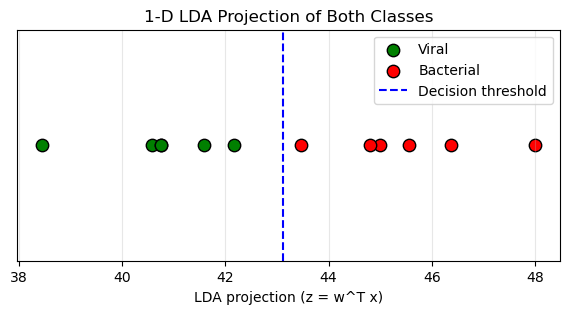

In [50]:
plt.figure(figsize=(7,3))
plt.scatter(proj1, np.zeros_like(proj1), c='green', label='Viral', s=80, edgecolor='k')
plt.scatter(proj2, np.zeros_like(proj2), c='red', label='Bacterial', s=80, edgecolor='k')
plt.axvline(threshold, color='blue', linestyle='--', label='Decision threshold')
plt.yticks([])
plt.xlabel('LDA projection (z = w^T x)')
plt.title('1-D LDA Projection of Both Classes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [51]:
##  try a new patient sample 


In [52]:
# Example: a new patient with CRP = 25.0 and Temperature = 38.0
new_patient = np.array([25.0, 38.0])
result = classify(new_patient)
label = 'Viral' if result == 0 else 'Bacterial'
print(f'New patient CRP={new_patient[0]}, Temp={new_patient[1]} -> Predicted class: {label}')

New patient CRP=25.0, Temp=38.0 -> Predicted class: Viral
